In [27]:
# ==============================================================================
# HR TECH - EMPLOYEE ATTRITION PREDICTION
# Classification Project
#
# Dataset:
# WA_Fn-UseC_-HR-Employee-Attrition.csv
#
# Objective:
# Predict whether an employee is likely to leave the organization.
#
# Analytics:
# 1. Data Loading
# 2. Data Understanding
# 3. Data Cleaning
# 4. Descriptive Analysis
# 5. Diagnostic Analysis
# 6. Data Visualization
# 7. Correlation Analysis
# 8. Feature Preparation
# 9. Machine Learning
# 10. Model Evaluation
# 11. Attrition Probability Prediction
# 12. Business Insights
# ==============================================================================


# ==============================================================================
# 0. IMPORT REQUIRED LIBRARIES
# ==============================================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# HR Tech – Employee Attrition Prediction ## Project Objective The objective of this project is to predict whether an employee is likely to leave the organization based on factors such as job role, tenure, job satisfaction, compensation, overtime, work-life balance, and other employee-related attributes. ### Business Problem Employee attrition can create significant costs for an organization because recruiting and training replacement employees requires time and resources. An employee attrition prediction system can help HR teams identify employees who may be at higher risk of leaving and take proactive retention actions. ---

In [28]:
# ==============================================================================
# 1. DATA LOADING
# ==============================================================================

print("=" * 80)
print("1. DATA LOADING")
print("=" * 80)

file_path = "WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

print("\nFirst 5 records:")
print(df.head())

1. DATA LOADING
Dataset loaded successfully.
Shape: (1470, 35)

First 5 records:
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1              

# 1. Data Loading In this stage, the HR Employee Attrition CSV dataset is loaded using Pandas. The dataset contains employee information such as: - Age - Department - Job Role - Monthly Income - Job Satisfaction - Environment Satisfaction - Overtime - Total Working Years - Years at Company - Years in Current Role - Years Since Last Promotion - Years With Current Manager - Attrition The target variable is `Attrition`. ---

In [29]:
# ==============================================================================
# 2. DATA UNDERSTANDING
# ==============================================================================

print("\n" + "=" * 80)
print("2. DATA UNDERSTANDING")
print("=" * 80)

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nTarget Variable Distribution:")
print(df["Attrition"].value_counts())

print("\nTarget Variable Percentage:")
print(df["Attrition"].value_counts(normalize=True) * 100)


2. DATA UNDERSTANDING

Dataset Shape:
(1470, 35)

Column Names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Data Types:
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount          

# 2. Data Understanding In this stage, the structure and characteristics of the dataset are examined. The following activities are performed: - Check dataset shape - Display column names - Check data types - Display sample records - Check missing values - Check duplicate records - Examine the target variable distribution The target variable contains two classes: - `Yes` – employee left the organization - `No` – employee stayed in the organization ---

In [30]:
# ==============================================================================
# 3. DATA CLEANING
# ==============================================================================

print("\n" + "=" * 80)
print("3. DATA CLEANING")
print("=" * 80)

# Remove duplicate records
df = df.drop_duplicates()

# Remove columns that contain constant or identifier information.
# These columns do not provide useful predictive information.
columns_to_drop = [
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
]

df = df.drop(columns=columns_to_drop, errors="ignore")

# Check missing values after cleaning
print("\nMissing values after cleaning:")
print(df.isnull().sum().sum())

print("\nDataset shape after cleaning:")
print(df.shape)

print("\nRemaining columns:")
print(df.columns.tolist())


3. DATA CLEANING

Missing values after cleaning:
0

Dataset shape after cleaning:
(1470, 31)

Remaining columns:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


# 3. Data Cleaning The dataset is cleaned before performing analysis and machine learning. The following activities are performed: - Remove duplicate records - Check missing values - Remove constant columns - Remove employee identifier columns - Remove columns that do not provide useful predictive information The following columns are removed: - `EmployeeCount` - `EmployeeNumber` - `Over18` - `StandardHours` These columns do not provide meaningful information for predicting employee attrition. ---

In [31]:
# ==============================================================================
# 4. DESCRIPTIVE ANALYSIS
# ==============================================================================

print("\n" + "=" * 80)
print("4. DESCRIPTIVE ANALYSIS")
print("=" * 80)

# Numerical descriptive statistics
print("\nNumerical Descriptive Statistics:")
print(df.describe())

# Attrition count
print("\nAttrition Count:")
print(df["Attrition"].value_counts())

# Attrition percentage
attrition_percentage = (
    df["Attrition"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nAttrition Percentage:")
print(attrition_percentage)

# Important HR variables
important_numeric = [
    "Age",
    "MonthlyIncome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "JobInvolvement",
    "WorkLifeBalance"
]

available_numeric = [
    col for col in important_numeric if col in df.columns
]

print("\nSelected Variable Statistics:")
print(df[available_numeric].describe())


4. DESCRIPTIVE ANALYSIS

Numerical Descriptive Statistics:
               Age    DailyRate  DistanceFromHome    Education  \
count  1470.000000  1470.000000       1470.000000  1470.000000   
mean     36.923810   802.485714          9.192517     2.912925   
std       9.135373   403.509100          8.106864     1.024165   
min      18.000000   102.000000          1.000000     1.000000   
25%      30.000000   465.000000          2.000000     2.000000   
50%      36.000000   802.000000          7.000000     3.000000   
75%      43.000000  1157.000000         14.000000     4.000000   
max      60.000000  1499.000000         29.000000     5.000000   

       EnvironmentSatisfaction   HourlyRate  JobInvolvement     JobLevel  \
count              1470.000000  1470.000000     1470.000000  1470.000000   
mean                  2.721769    65.891156        2.729932     2.063946   
std                   1.093082    20.329428        0.711561     1.106940   
min                   1.000000    30.0000

# 4. Descriptive Analysis Descriptive analysis is used to understand what has happened in the employee dataset. Statistical measures such as the following are calculated: - Count - Mean - Standard deviation - Minimum - Maximum - Quartiles Important employee variables are analyzed, including: - Age - Monthly Income - Total Working Years - Years at Company - Job Satisfaction - Environment Satisfaction - Job Involvement - Work-Life Balance The overall percentage of employees who left the organization is also calculated. ---

In [32]:
# ==============================================================================
# 5. DIAGNOSTIC ANALYSIS
# ==============================================================================

print("\n" + "=" * 80)
print("5. DIAGNOSTIC ANALYSIS")
print("=" * 80)

# Attrition by overtime
print("\nAttrition by OverTime:")
print(
    pd.crosstab(
        df["OverTime"],
        df["Attrition"],
        normalize="index"
    ).round(3)
)

# Attrition by job role
print("\nAttrition by Job Role:")
print(
    pd.crosstab(
        df["JobRole"],
        df["Attrition"],
        normalize="index"
    ).round(3)
)

# Attrition by department
print("\nAttrition by Department:")
print(
    pd.crosstab(
        df["Department"],
        df["Attrition"],
        normalize="index"
    ).round(3)
)

# Attrition by business travel
print("\nAttrition by Business Travel:")
print(
    pd.crosstab(
        df["BusinessTravel"],
        df["Attrition"],
        normalize="index"
    ).round(3)
)

# Average values for employees who left vs stayed
diagnostic_columns = [
    "Age",
    "MonthlyIncome",
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "JobInvolvement",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

diagnostic_columns = [
    col for col in diagnostic_columns if col in df.columns
]

print("\nAverage values by Attrition:")
print(
    df.groupby("Attrition")[diagnostic_columns]
    .mean()
    .round(2)
)


5. DIAGNOSTIC ANALYSIS

Attrition by OverTime:
Attrition     No    Yes
OverTime               
No         0.896  0.104
Yes        0.695  0.305

Attrition by Job Role:
Attrition                     No    Yes
JobRole                                
Healthcare Representative  0.931  0.069
Human Resources            0.769  0.231
Laboratory Technician      0.761  0.239
Manager                    0.951  0.049
Manufacturing Director     0.931  0.069
Research Director          0.975  0.025
Research Scientist         0.839  0.161
Sales Executive            0.825  0.175
Sales Representative       0.602  0.398

Attrition by Department:
Attrition                  No    Yes
Department                          
Human Resources         0.810  0.190
Research & Development  0.862  0.138
Sales                   0.794  0.206

Attrition by Business Travel:
Attrition             No    Yes
BusinessTravel                 
Non-Travel         0.920  0.080
Travel_Frequently  0.751  0.249
Travel_Rarely      0.8

# 5. Diagnostic Analysis Diagnostic analysis investigates why employee attrition may be occurring. The relationship between attrition and different employee characteristics is examined. Examples include: - Attrition vs Overtime - Attrition vs Job Role - Attrition vs Department - Attrition vs Business Travel - Attrition vs Job Satisfaction - Attrition vs Monthly Income - Attrition vs Years at Company Average employee characteristics are also compared between employees who stayed and employees who left. This helps identify possible factors associated with employee attrition. ---


6. DATA VISUALIZATION


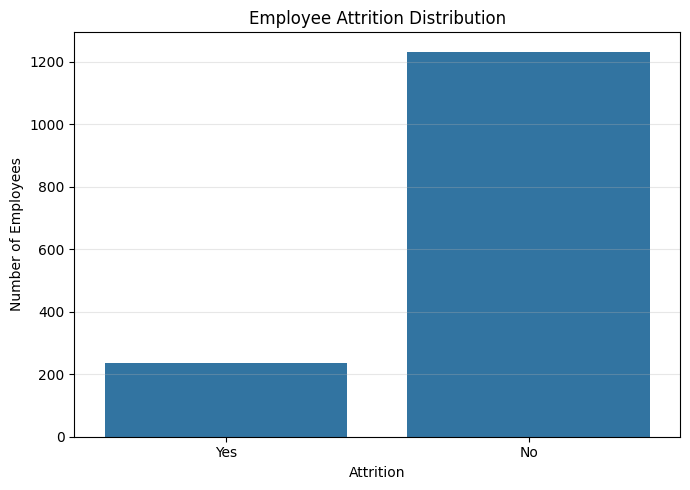

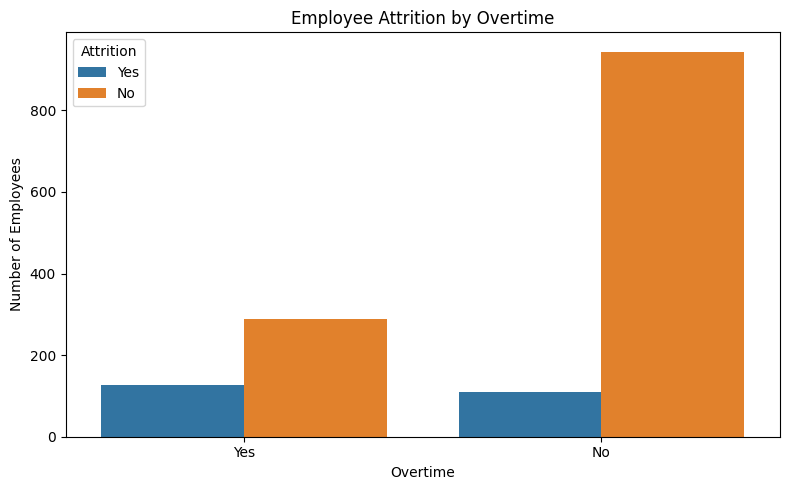

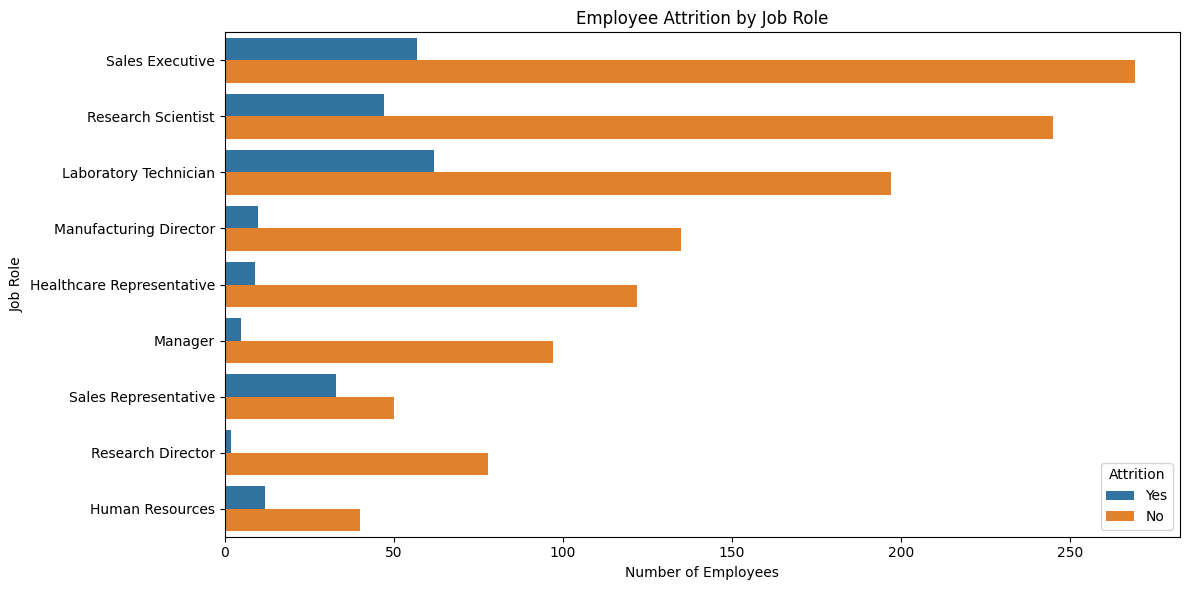

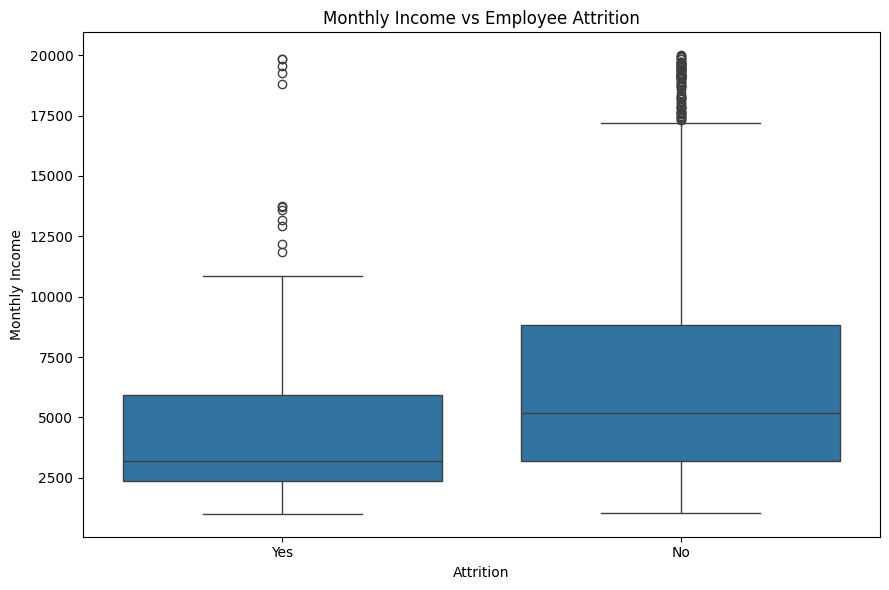

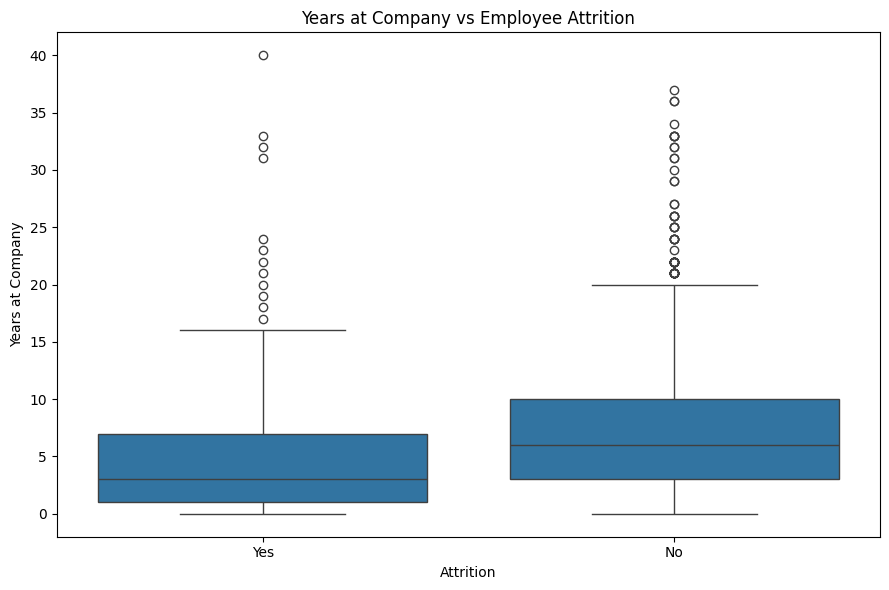

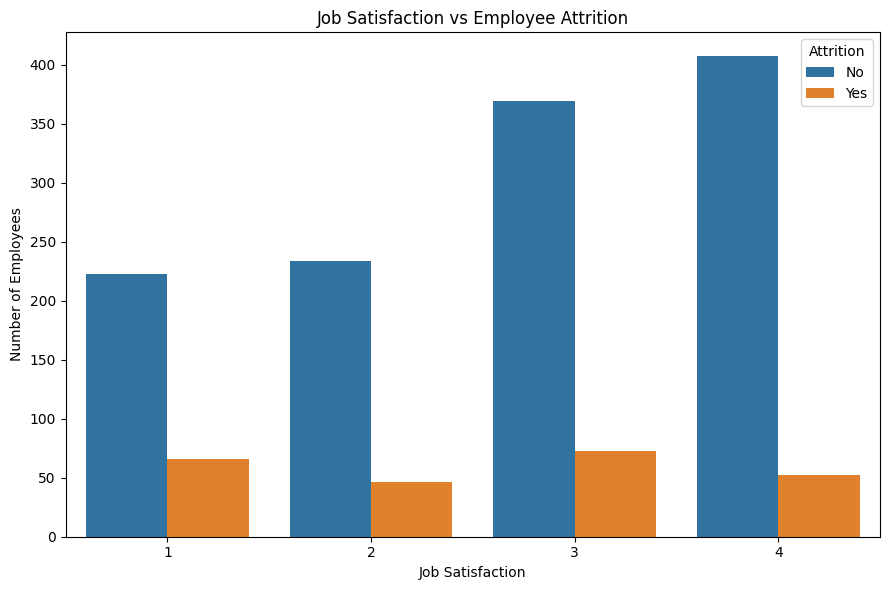

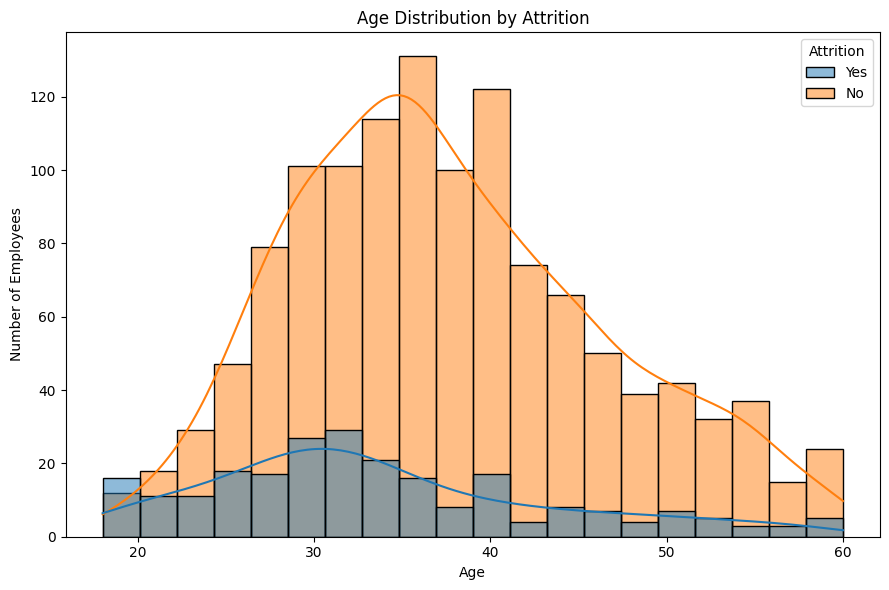

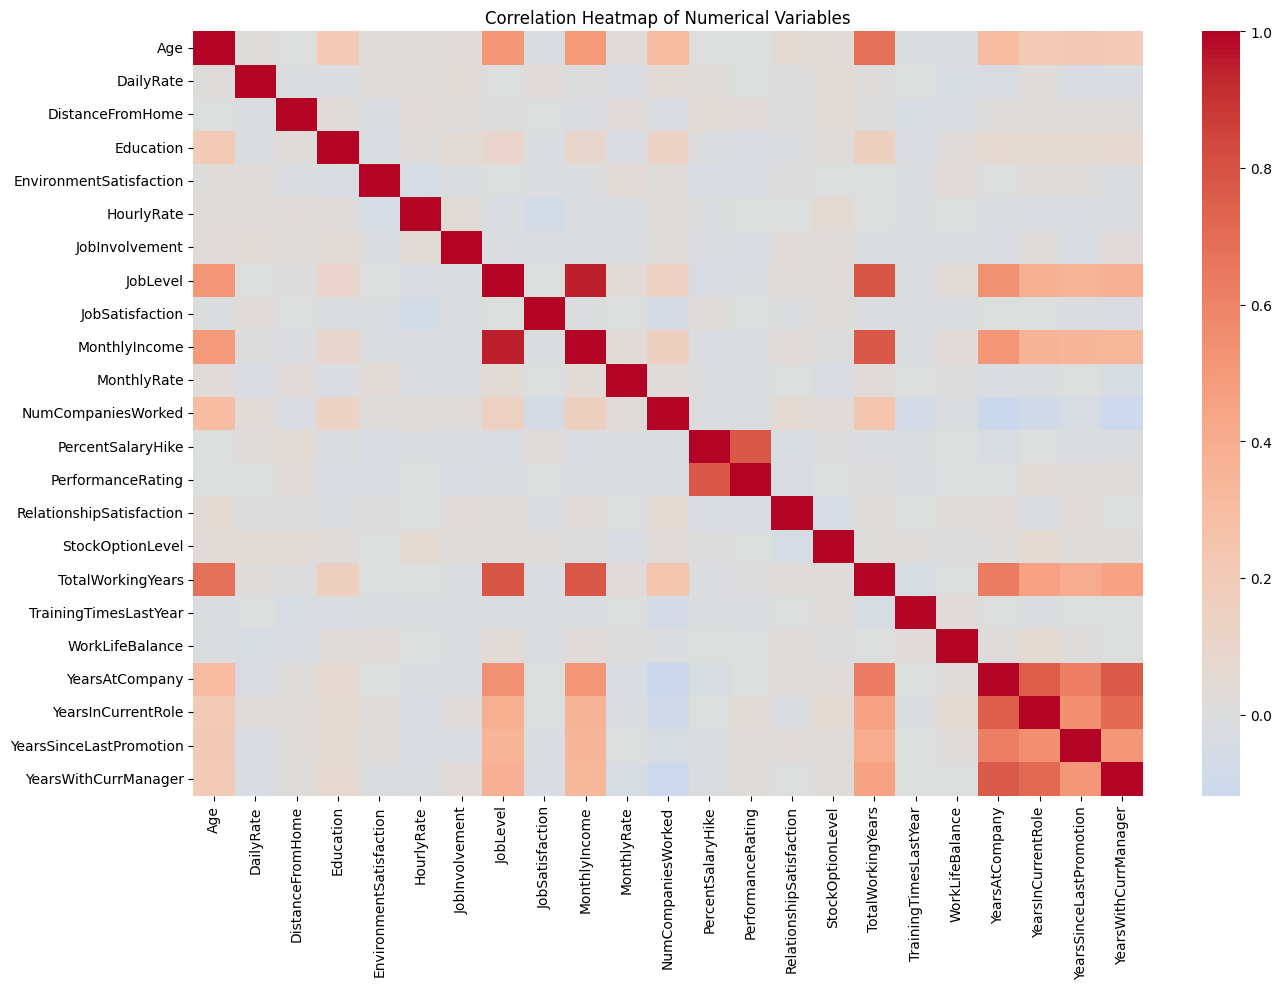

In [33]:
# ==============================================================================
# 6. DATA VISUALIZATION
# ==============================================================================

print("\n" + "=" * 80)
print("6. DATA VISUALIZATION")
print("=" * 80)


# ------------------------------------------------------------------------------
# 6.1 Attrition Distribution
# ------------------------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Attrition"
)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------------------
# 6.2 Attrition by Overtime
# ------------------------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="OverTime",
    hue="Attrition"
)

plt.title("Employee Attrition by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------------------
# 6.3 Attrition by Job Role
# ------------------------------------------------------------------------------

plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    y="JobRole",
    hue="Attrition"
)

plt.title("Employee Attrition by Job Role")
plt.xlabel("Number of Employees")
plt.ylabel("Job Role")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------------------
# 6.4 Monthly Income vs Attrition
# ------------------------------------------------------------------------------

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income vs Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------------------
# 6.5 Years at Company vs Attrition
# ------------------------------------------------------------------------------

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Attrition",
    y="YearsAtCompany"
)

plt.title("Years at Company vs Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Years at Company")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------------------
# 6.6 Job Satisfaction vs Attrition
# ------------------------------------------------------------------------------

plt.figure(figsize=(9, 6))

sns.countplot(
    data=df,
    x="JobSatisfaction",
    hue="Attrition"
)

plt.title("Job Satisfaction vs Employee Attrition")
plt.xlabel("Job Satisfaction")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------------------
# 6.7 Age Distribution
# ------------------------------------------------------------------------------

plt.figure(figsize=(9, 6))

sns.histplot(
    data=df,
    x="Age",
    hue="Attrition",
    kde=True,
    bins=20
)

plt.title("Age Distribution by Attrition")
plt.xlabel("Age")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------------------
# 6.8 Correlation Heatmap
# ------------------------------------------------------------------------------

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14, 10))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.tight_layout()
plt.show()

# 6. Data Visualization Visualization is used to communicate important patterns in the dataset. The project creates visualizations for: - Employee attrition distribution - Attrition by overtime - Attrition by job role - Monthly income vs attrition - Years at company vs attrition - Job satisfaction vs attrition - Age distribution - Correlation heatmap - Model comparison - Confusion matrix - ROC curve - Attrition risk distribution - Attrition probability distribution Visualization makes it easier to identify patterns and relationships that may not be obvious from numerical analysis alone. ---

In [34]:
# ==============================================================================
# 7. CORRELATION ANALYSIS
# ==============================================================================

print("\n" + "=" * 80)
print("7. CORRELATION ANALYSIS")
print("=" * 80)

correlation_matrix = numeric_df.corr()

print("\nCorrelation Matrix:")
print(correlation_matrix.round(2))

# Correlation with selected variables
print("\nCorrelation with Monthly Income:")

if "MonthlyIncome" in correlation_matrix.columns:
    print(
        correlation_matrix["MonthlyIncome"]
        .sort_values(ascending=False)
        .round(3)
    )

print("\nCorrelation with YearsAtCompany:")

if "YearsAtCompany" in correlation_matrix.columns:
    print(
        correlation_matrix["YearsAtCompany"]
        .sort_values(ascending=False)
        .round(3)
    )


7. CORRELATION ANALYSIS

Correlation Matrix:
                           Age  DailyRate  DistanceFromHome  Education  \
Age                       1.00       0.01             -0.00       0.21   
DailyRate                 0.01       1.00             -0.00      -0.02   
DistanceFromHome         -0.00      -0.00              1.00       0.02   
Education                 0.21      -0.02              0.02       1.00   
EnvironmentSatisfaction   0.01       0.02             -0.02      -0.03   
HourlyRate                0.02       0.02              0.03       0.02   
JobInvolvement            0.03       0.05              0.01       0.04   
JobLevel                  0.51       0.00              0.01       0.10   
JobSatisfaction          -0.00       0.03             -0.00      -0.01   
MonthlyIncome             0.50       0.01             -0.02       0.09   
MonthlyRate               0.03      -0.03              0.03      -0.03   
NumCompaniesWorked        0.30       0.04             -0.03       

# 7. Correlation Analysis Correlation analysis measures the relationship between numerical employee variables. A correlation matrix is generated for numerical variables. The analysis examines relationships involving variables such as: - Age - Monthly Income - Total Working Years - Years at Company - Years in Current Role - Years Since Last Promotion - Years With Current Manager - Job Satisfaction - Job Involvement - Work-Life Balance A correlation heatmap is also created to visually identify stronger positive and negative relationships. ---

In [35]:
# ==============================================================================
# 8. FEATURE PREPARATION
# ==============================================================================

print("\n" + "=" * 80)
print("8. FEATURE PREPARATION")
print("=" * 80)

# Convert target variable to binary
df["Attrition_Target"] = df["Attrition"].map({
    "No": 0,
    "Yes": 1
})

# Remove original target
X = df.drop(
    columns=["Attrition", "Attrition_Target"]
)

y = df["Attrition_Target"]

# Identify numerical and categorical columns
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nNumerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

print("\nTarget Distribution:")
print(y.value_counts())


8. FEATURE PREPARATION

Numerical Features:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical Features:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Target Distribution:
Attrition_Target
0    1233
1     237
Name: count, dtype: int64


# 8. Feature Preparation Machine learning algorithms require the data to be converted into an appropriate numerical format. The `Attrition` target variable is converted into binary values: - `No` → 0 - `Yes` → 1 The input variables are separated into: ### Numerical Features Examples: - Age - Monthly Income - Distance From Home - Total Working Years - Years At Company ### Categorical Features Examples: - Business Travel - Department - Education Field - Job Role - Marital Status - OverTime Numerical variables are standardized using `StandardScaler`. Categorical variables are converted into numerical representations using `OneHotEncoder`. ---

In [36]:
# ==============================================================================
# 9. MACHINE LEARNING
# ==============================================================================

print("\n" + "=" * 80)
print("9. MACHINE LEARNING")
print("=" * 80)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])


# ------------------------------------------------------------------------------
# Preprocessing Pipeline
# ------------------------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)


# ------------------------------------------------------------------------------
# Model 1: Logistic Regression
# ------------------------------------------------------------------------------

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistic_model.fit(
    X_train,
    y_train
)

logistic_predictions = logistic_model.predict(X_test)

logistic_probabilities = logistic_model.predict_proba(
    X_test
)[:, 1]


# ------------------------------------------------------------------------------
# Model 2: Random Forest
# ------------------------------------------------------------------------------

random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced",
                max_depth=10
            )
        )
    ]
)

random_forest_model.fit(
    X_train,
    y_train
)

rf_predictions = random_forest_model.predict(X_test)

rf_probabilities = random_forest_model.predict_proba(
    X_test
)[:, 1]


9. MACHINE LEARNING
Training records: 1176
Testing records: 294


# 9. Machine Learning This project uses classification algorithms to predict employee attrition. Two machine learning models are trained: ### Logistic Regression Logistic Regression is a classification algorithm that predicts the probability that an employee belongs to the attrition class. It is useful because the model is relatively easy to interpret. ### Random Forest Random Forest is an ensemble machine learning algorithm that combines multiple decision trees. It can capture nonlinear relationships between employee characteristics and attrition. The dataset is divided into: - 80% Training Data - 20% Testing Data Stratified sampling is used to maintain the proportion of attrition classes. ---


10. MODEL EVALUATION

------------------------------------------------------------
Logistic Regression
------------------------------------------------------------
Accuracy : 0.7517
Precision: 0.3488
Recall   : 0.6383
F1 Score : 0.4511
ROC-AUC  : 0.8032

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.92      0.77      0.84       247
        Left       0.35      0.64      0.45        47

    accuracy                           0.75       294
   macro avg       0.63      0.71      0.65       294
weighted avg       0.83      0.75      0.78       294

Confusion Matrix:
[[191  56]
 [ 17  30]]

------------------------------------------------------------
Random Forest
------------------------------------------------------------
Accuracy : 0.8401
Precision: 0.5000
Recall   : 0.1489
F1 Score : 0.2295
ROC-AUC  : 0.7975

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.86      0.97      0.91    

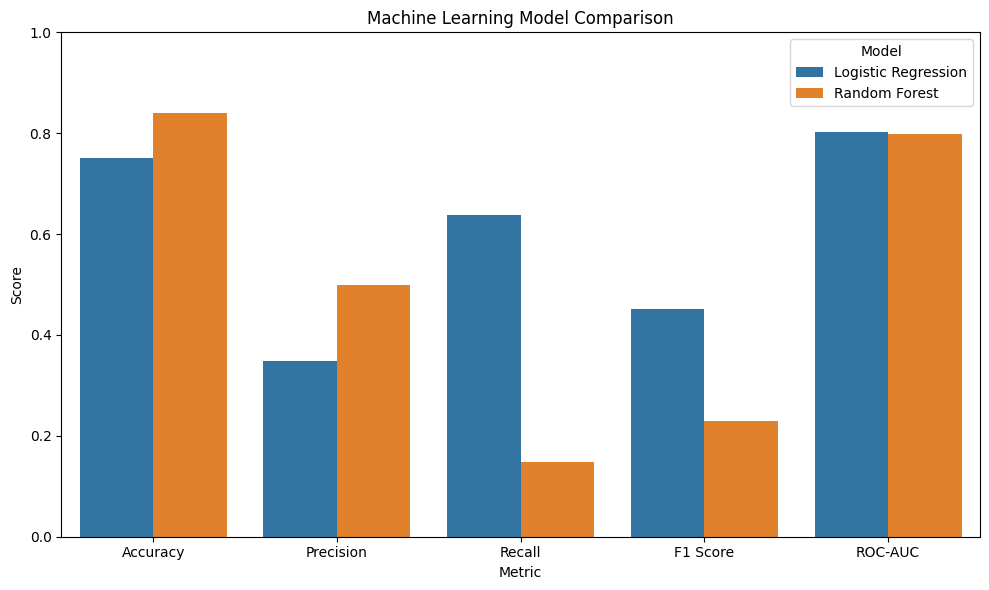


Best Model based on F1 Score:
Logistic Regression


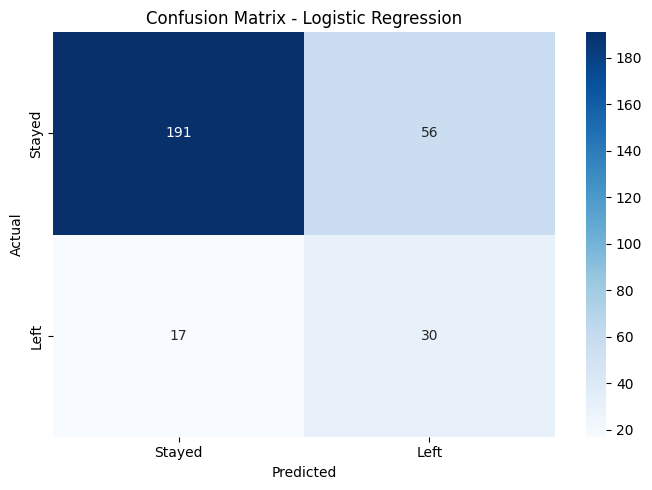

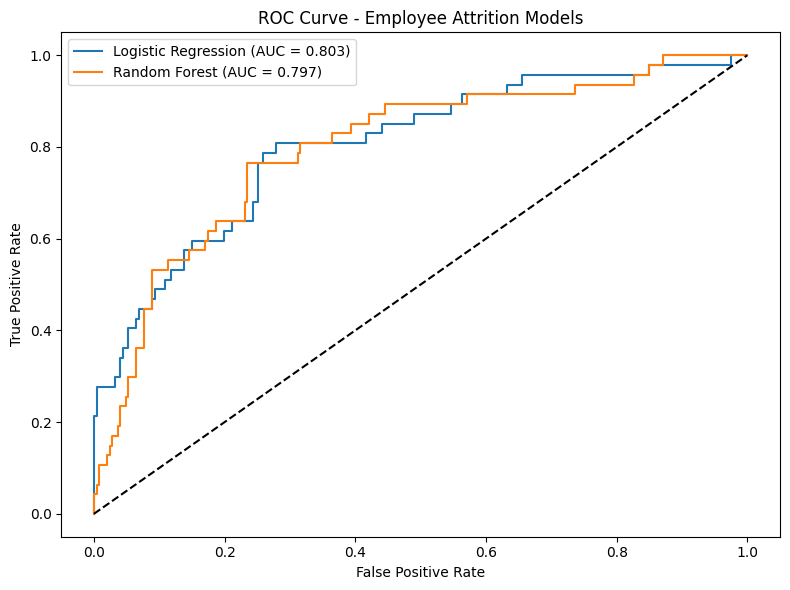

In [37]:
# ==============================================================================
# 10. MODEL EVALUATION
# ==============================================================================

print("\n" + "=" * 80)
print("10. MODEL EVALUATION")
print("=" * 80)


def evaluate_model(
    model_name,
    y_true,
    predictions,
    probabilities
):

    accuracy = accuracy_score(
        y_true,
        predictions
    )

    precision = precision_score(
        y_true,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        predictions,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_true,
        probabilities
    )

    print("\n" + "-" * 60)
    print(model_name)
    print("-" * 60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            predictions,
            target_names=["Stayed", "Left"],
            zero_division=0
        )
    )

    print("Confusion Matrix:")

    cm = confusion_matrix(
        y_true,
        predictions
    )

    print(cm)

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }


logistic_results = evaluate_model(
    "Logistic Regression",
    y_test,
    logistic_predictions,
    logistic_probabilities
)

rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_predictions,
    rf_probabilities
)


# ------------------------------------------------------------------------------
# Model Comparison
# ------------------------------------------------------------------------------

results_df = pd.DataFrame([
    logistic_results,
    rf_results
])

print("\nModel Comparison:")
print(
    results_df.round(4)
)


# ------------------------------------------------------------------------------
# Model Comparison Visualization
# ------------------------------------------------------------------------------

plt.figure(figsize=(10, 6))

results_melted = results_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    var_name="Metric",
    value_name="Score"
)

sns.barplot(
    data=results_melted,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Machine Learning Model Comparison")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------------------
# Confusion Matrix - Best Model
# ------------------------------------------------------------------------------

# Select model based on F1 score
best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(),
    "Model"
]

print("\nBest Model based on F1 Score:")
print(best_model_name)

if best_model_name == "Logistic Regression":
    best_predictions = logistic_predictions
    best_probabilities = logistic_probabilities
else:
    best_predictions = rf_predictions
    best_probabilities = rf_probabilities


cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Left"],
    yticklabels=["Stayed", "Left"]
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------------------
# ROC Curve
# ------------------------------------------------------------------------------

logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    logistic_probabilities
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic Regression "
          f"(AUC = {roc_auc_score(y_test, logistic_probabilities):.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest "
          f"(AUC = {roc_auc_score(y_test, rf_probabilities):.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    "k--"
)

plt.title("ROC Curve - Employee Attrition Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.show()

# 10. Model Evaluation The machine learning models are evaluated using: ### Accuracy Measures the overall percentage of correct predictions. ### Precision Measures how many employees predicted as leaving actually leave. ### Recall Measures how many employees who actually leave are correctly identified. ### F1 Score The F1 score combines precision and recall. ### ROC-AUC Measures the model's ability to distinguish between employees who stay and employees who leave. A confusion matrix and ROC curve are also generated. For an employee retention problem, recall is particularly important because HR may want to identify as many genuinely high-risk employees as possible. ---


11. ATTRITION PROBABILITY PREDICTION

Employee Attrition Risk Predictions:
      Age                 JobRole              Department  MonthlyIncome  \
1061   24    Sales Representative                   Sales           2033   
891    44      Research Scientist  Research & Development           2011   
456    31                 Manager                   Sales          11557   
922    44                 Manager  Research & Development          19190   
69     36      Research Scientist  Research & Development           3388   
1164   40  Manufacturing Director  Research & Development           7945   
406    52  Manufacturing Director  Research & Development           7969   
1330   43                 Manager  Research & Development          19392   
1232   35  Manufacturing Director  Research & Development           6883   
1311   18      Research Scientist  Research & Development           1514   
1212   34      Research Scientist  Research & Development           2929   
771    54   

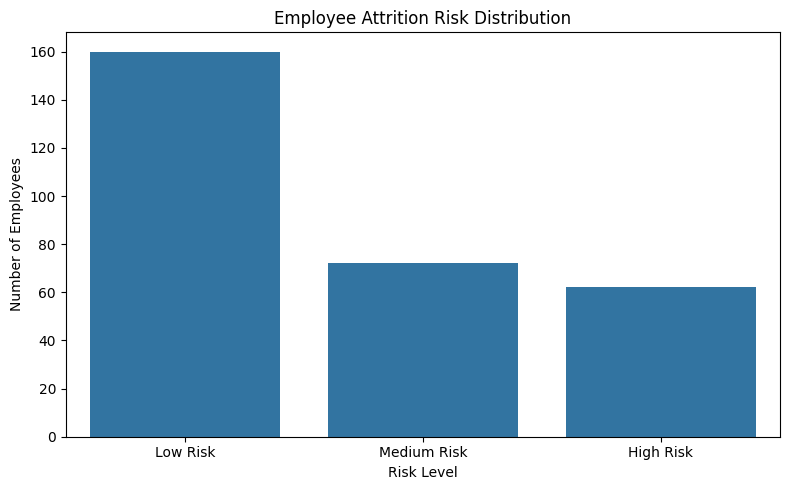

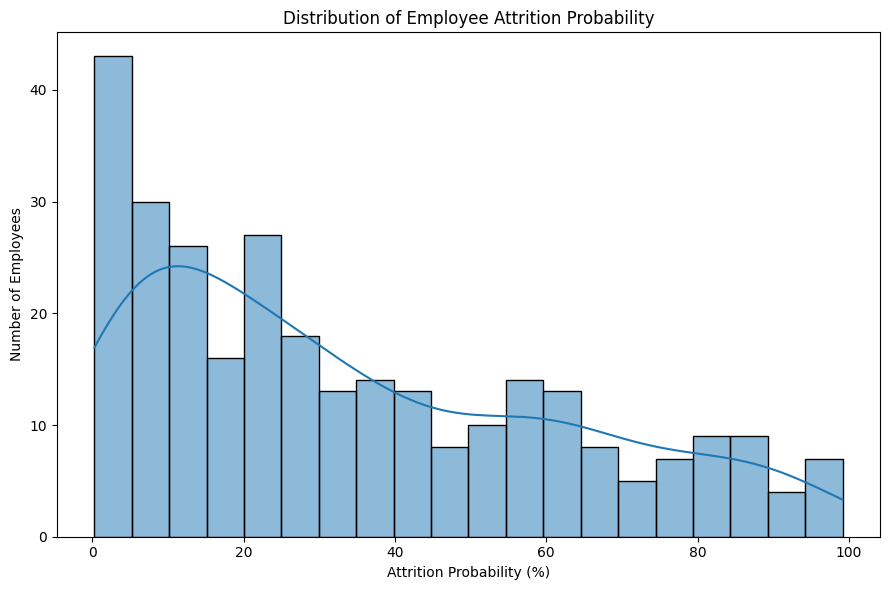

In [38]:
# ==============================================================================
# 11. ATTRITION PROBABILITY PREDICTION
# ==============================================================================

print("\n" + "=" * 80)
print("11. ATTRITION PROBABILITY PREDICTION")
print("=" * 80)

# Create a copy of test data
prediction_results = X_test.copy()

prediction_results["Actual_Attrition"] = y_test.values

prediction_results["Attrition_Probability"] = (
    best_probabilities * 100
).round(2)

prediction_results["Predicted_Attrition"] = np.where(
    best_probabilities >= 0.50,
    "Yes",
    "No"
)

# Risk category
prediction_results["Risk_Level"] = pd.cut(
    best_probabilities,
    bins=[-np.inf, 0.30, 0.60, np.inf],
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

print("\nEmployee Attrition Risk Predictions:")

columns_to_display = [
    col for col in [
        "Age",
        "JobRole",
        "Department",
        "MonthlyIncome",
        "JobSatisfaction",
        "OverTime",
        "YearsAtCompany",
        "Actual_Attrition",
        "Attrition_Probability",
        "Predicted_Attrition",
        "Risk_Level"
    ]
    if col in prediction_results.columns
]

print(
    prediction_results[
        columns_to_display
    ].head(20)
)


# ------------------------------------------------------------------------------
# High-Risk Employees
# ------------------------------------------------------------------------------

high_risk_employees = prediction_results[
    prediction_results["Risk_Level"] == "High Risk"
].copy()

high_risk_employees = high_risk_employees.sort_values(
    by="Attrition_Probability",
    ascending=False
)

print("\nNumber of High-Risk Employees:")
print(len(high_risk_employees))

print("\nTop High-Risk Employees:")

print(
    high_risk_employees[
        columns_to_display
    ].head(20)
)


# ------------------------------------------------------------------------------
# Risk Distribution Visualization
# ------------------------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.countplot(
    data=prediction_results,
    x="Risk_Level"
)

plt.title("Employee Attrition Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------------------
# Attrition Probability Distribution
# ------------------------------------------------------------------------------

plt.figure(figsize=(9, 6))

sns.histplot(
    prediction_results["Attrition_Probability"],
    bins=20,
    kde=True
)

plt.title("Distribution of Employee Attrition Probability")
plt.xlabel("Attrition Probability (%)")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

# 11. Attrition Probability Prediction The trained model generates an attrition probability for each employee. The probability is converted into three risk categories: - Low Risk - Medium Risk - High Risk Example: | Probability | Risk Level | |-------------|------------| | Below 30% | Low Risk | | 30% – 60% | Medium Risk | | Above 60% | High Risk | Employees with a high predicted probability of attrition can be prioritized for further HR review. ---

In [39]:
# ==============================================================================
# 12. BUSINESS INSIGHTS
# ==============================================================================

print("\n" + "=" * 80)
print("12. BUSINESS INSIGHTS")
print("=" * 80)

print("""
Key business questions answered by this project:

1. How many employees are leaving the organization?

2. Which job roles have higher attrition?

3. Does overtime appear to be associated with employee attrition?

4. Does job satisfaction differ between employees who stay and leave?

5. Does compensation influence attrition?

6. Does tenure influence attrition?

7. Which employee characteristics are associated with higher attrition?

8. Which machine learning model performs better?

9. Which employees have a high predicted probability of leaving?

10. How can HR use attrition predictions for proactive retention?
""")

print("\nProject completed successfully.")



12. BUSINESS INSIGHTS

Key business questions answered by this project:

1. How many employees are leaving the organization?

2. Which job roles have higher attrition?

3. Does overtime appear to be associated with employee attrition?

4. Does job satisfaction differ between employees who stay and leave?

5. Does compensation influence attrition?

6. Does tenure influence attrition?

7. Which employee characteristics are associated with higher attrition?

8. Which machine learning model performs better?

9. Which employees have a high predicted probability of leaving?

10. How can HR use attrition predictions for proactive retention?


Project completed successfully.


# 12. Business Insights The analysis helps HR answer important questions such as: - Which employees are most likely to leave? - Which job roles have higher attrition? - Is overtime associated with attrition? - Does employee satisfaction affect attrition? - Does compensation appear to influence attrition? - Does tenure influence attrition? - Which factors are associated with employee turnover? - Which machine learning model performs better? - Which employees have high predicted attrition probability? These insights can support proactive employee retention strategies. ---